# ALEX smFRET: 2D E–S analysis

A full micro-second-ALEX single-molecule FRET experiment, simulated end to end. Two **diffusing** populations (FRET efficiency E≈0.2 and E≈0.8) at a common stoichiometry are simulated, exported to the ISS `SM` container, and analysed: fold the macro-time to recover the excitation windows, burst-search, count the DD / DA / AA streams per burst, and build the **2D E–S histogram** that separates FRET (varying E) from labelling stoichiometry (varying S).

In [1]:
%matplotlib inline
import numpy as np, tttrlib, tempfile, os

SM_CONTAINER, SM_RECORD, TY_F8 = 7, 11, 536870920

def sim_photon_arrays(ph, dt, macro_res):
    """Photon-only (macro_int, micro, routing) from SimEngine.photons() at a chosen resolution."""
    photon = ph["event_type"] == 0
    mw = ph["macro_window"][photon].astype(np.float64)
    arr = ph["arrival_time"][photon].astype(np.float64)
    macro = np.floor((mw * dt + arr) / macro_res).astype(np.uint64)
    order = np.argsort(macro, kind="stable")
    return (macro[order], ph["micro_time"][photon][order].astype(np.uint16),
            ph["channel"][photon][order].astype(np.int8))

def sim_photons_to_tttr(ph, dt, macro_res, container="SM", record_type=SM_RECORD, container_id=SM_CONTAINER):
    """Build a TTTR (photons only) from photons(). SM keeps macro+routing; PTU/Photon-HDF5 keep micro too."""
    macro, micro, routing = sim_photon_arrays(ph, dt, macro_res)
    d = tttrlib.TTTR(); d.append_events(macro, micro, routing, np.zeros(len(macro), np.int8))
    d.header.tttr_container_type = container_id; d.header.tttr_record_type = record_type
    d.header.set_tag("MeasDesc_GlobalResolution", macro_res, TY_F8)
    fn = tempfile.mktemp(suffix="." + container.lower().replace("-", ""))
    try:
        d.write(fn); return tttrlib.TTTR(fn, container)
    finally:
        if os.path.isfile(fn): os.unlink(fn)

def _contiguous_runs(mask):
    mask = np.asarray(mask, bool); n = len(mask)
    if n == 0 or not mask.any(): return []
    if mask.all(): return [(0, n - 1)]
    off = int(np.argmin(mask)); rolled = np.roll(mask, -off); runs = []; i = 0
    while i < n:
        if rolled[i]:
            j = i
            while j < n and rolled[j]: j += 1
            runs.append(((i + off) % n, (j - 1 + off) % n)); i = j
        else: i += 1
    return runs

def auto_alex_windows(phase, rc, donor_ch, acceptor_ch, period, n_bins=200, guard=0.06, occ=0.3):
    """Detect green/red ALEX windows from the folded phase using the donor detector.

    The donor detector is lit only under green excitation, so its phase histogram marks the green
    window; the red window is where the donor is dark but the acceptor is lit. Works with or
    without rise/fall gaps between the two laser windows.
    """
    phase = np.asarray(phase); rc = np.asarray(rc)
    edges = np.linspace(0, period, n_bins + 1)
    dc, _ = np.histogram(phase[np.isin(rc, donor_ch)], bins=edges)
    ac, _ = np.histogram(phase[np.isin(rc, acceptor_ch)], bins=edges)
    if dc.sum() == 0 or ac.sum() == 0:
        raise ValueError("need both donor and acceptor photons")
    rs = lambda c, r: (c[r[0]:r[1]+1].sum() if r[0] <= r[1] else c[r[0]:].sum() + c[:r[1]+1].sum())
    d_on = dc > occ * np.percentile(dc[dc > 0], 75)
    greens = _contiguous_runs(d_on)
    if not greens: raise ValueError("no green window")
    green = max(greens, key=lambda r: rs(dc, r))
    reds = _contiguous_runs((~d_on) & (ac > occ * np.percentile(ac[ac > 0], 75)))
    if not reds: raise ValueError("no red window - not ALEX?")
    red = max(reds, key=lambda r: rs(ac, r))
    def win(run):
        s, e = run
        lo = float(edges[s]); hi = float(edges[e+1]) if e+1 < len(edges) else float(period)
        m = guard * ((hi - lo) if hi > lo else (period - lo + hi))
        return (lo + m, hi - m)
    return {"green": win(green), "red": win(red), "phase_hist_edges": edges}


In [2]:
import json, matplotlib.pyplot as plt
cfg = json.load(open(r"/Users/tpeulen/dev/tttrlib/examples/simulation/configs/alex.json")); cfg.pop("_comment", None)
dt = cfg["settings"]["dt"]; macro_res = dt / 1024
period_ticks = int(round(cfg["settings"]["alex_period"] / macro_res))
e = tttrlib.SimEngine.from_dict(cfg); e.run()
ph = e.photons()
print("photons:", (ph["event_type"]==0).sum(), " period_ticks:", period_ticks)

photons: 600001  period_ticks: 10240


## Export to ISS `SM`, fold, and auto-detect the windows

In [3]:
t = sim_photons_to_tttr(ph, dt, macro_res, container="SM")
t.alex_to_microtime(period_ticks, 0)
phase = np.asarray(t.micro_times); rc = np.asarray(t.routing_channels)
win = auto_alex_windows(phase, rc, [0], [1], period_ticks)
g_lo, g_hi = win["green"]; r_lo, r_hi = win["red"]
green = (phase >= g_lo) & (phase < g_hi); red = (phase >= r_lo) & (phase < r_hi)
print("green", (round(g_lo), round(g_hi)), " red", (round(r_lo), round(r_hi)),
      " retention=%.2f" % (green | red).mean())

green (307, 4813)  red (5427, 9933)  retention=0.88


## Burst search and per-burst DD / DA / AA

An all-photon sliding-window burst search finds single-molecule transits; for each burst we count the three ALEX streams and form `E = DA/(DD+DA)` and `S = (DD+DA)/(DD+DA+AA)`.

In [4]:
bursts = np.asarray(t.burst_search(L=40, m=10, T=0.5, mode="sliding_window")).reshape(-1, 2)
i_dd = np.zeros(len(bursts)); i_da = np.zeros(len(bursts)); i_aa = np.zeros(len(bursts))
for k, (s, en) in enumerate(bursts):
    sl = slice(int(s), int(en)+1); gg = green[sl]; rr = red[sl]; cc = rc[sl]
    i_dd[k] = np.count_nonzero(gg & (cc==0)); i_da[k] = np.count_nonzero(gg & (cc==1))
    i_aa[k] = np.count_nonzero(rr & (cc==1))
grn = i_dd + i_da
E = np.divide(i_da, grn, out=np.zeros_like(i_da), where=grn>0)
S = np.divide(grn, grn + i_aa, out=np.zeros_like(grn), where=(grn+i_aa)>0)
sel = (grn + i_aa) > 30
E, S = E[sel], S[sel]
print("%d bursts;  low-E %.3f (0.20)  high-E %.3f (0.80)  S %.3f"
      % (sel.sum(), E[E<0.5].mean(), E[E>=0.5].mean(), S.mean()))

3385 bursts;  low-E 0.199 (0.20)  high-E 0.798 (0.80)  S 0.461


## The 2D E–S histogram

The two FRET populations separate along **E** at a common **S** (both are doubly labelled).

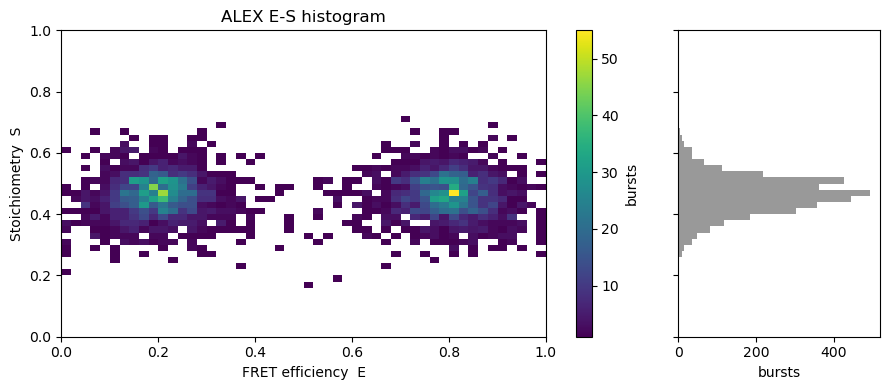

In [5]:
fig, (axm, axs) = plt.subplots(1, 2, figsize=(9, 4),
        gridspec_kw=dict(width_ratios=[3, 1]), sharey=True)
h = axm.hist2d(E, S, bins=50, range=[[0, 1], [0, 1]], cmap="viridis", cmin=1)
fig.colorbar(h[3], ax=axm, label="bursts")
axm.set_xlabel("FRET efficiency  E"); axm.set_ylabel("Stoichiometry  S")
axm.set_title("ALEX E-S histogram")
axs.hist(S, bins=50, range=(0, 1), orientation="horizontal", color="0.6")
axs.set_xlabel("bursts")
plt.tight_layout(); plt.show()

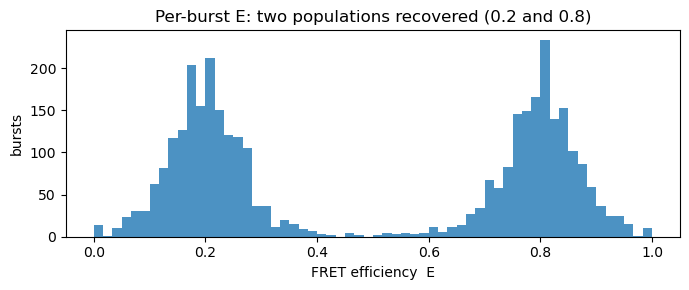

In [6]:
fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(E, bins=60, range=(0, 1), color="tab:blue", alpha=0.8)
ax.set_xlabel("FRET efficiency  E"); ax.set_ylabel("bursts")
ax.set_title("Per-burst E: two populations recovered (0.2 and 0.8)")
plt.tight_layout(); plt.show()